<a href="https://colab.research.google.com/github/varshitaneyyila/Credit-Risk-prediction-ML-pipeline/blob/main/group_5_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Risk Prediction — ML Pipeline
### Capstone Assignment | Binary Classification
**Dataset:** Credit Risk | **Task:** Binary Classification

---

## Objective
Predict whether a borrower will **default on a loan** using three financial features.
Compare two preprocessing strategies across two classifiers to find the best pipeline.

## Dataset Description
- **Source:** — Credit Risk Dataset
- **Size:** 10,000 rows × 4 columns

| Feature | Type | Description |
|---|---|---|
| Employed | int | Employment status (0 = unemployed, 1 = employed) |
| Bank Balance | float | Current bank balance |
| Annual Salary | float | Yearly income |
| Defaulted? | int | Target — 1 = default, 0 = no default |

- **Key challenge:** Severe class imbalance — 29:1 ratio (9,667 non-defaulters vs 333 defaulters)

## Expected Output
- EDA visualisations (class distribution, correlations, feature plots)
- 4 trained pipelines (2 models × 2 preprocessing strategies)
- Metric comparison table (Accuracy, Precision, Recall, F1, ROC-AUC)
- Best model evaluated on held-out test set
- Feature importance chart + final recommendation

---

## 1. Problem Formulation
**Problem:** Predict whether a borrower will default on a loan.

**Input:** Employed, Bank Balance, Annual Salary
**Output:** Defaulted — 1 (yes) or 0 (no)
**Task Type:** Binary Classification

**Motivation:** Banks lose money approving loans to defaulters. An ML model
that predicts default risk helps banks make better lending decisions, reducing
financial loss while serving creditworthy customers.

## Imports & Setup

We import all required libraries upfront:
- **pandas / numpy** — data manipulation and numerical operations
- **matplotlib / seaborn** — visualisations
- **scikit-learn** — preprocessing, modelling, and evaluation metrics
- **imbalanced-learn** — SMOTE oversampling to handle class imbalance

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

### Download Dataset Automatically

To avoid manual uploads and make the notebook runnable by anyone, we'll download the `credit risk.csv` file directly from a public source. You can replace the URL below with your own public link (e.g., a raw GitHub link or a direct Google Drive download link) if you host the file elsewhere.

Make sure the downloaded file name matches the one used in `pd.read_csv`.

In [ ]:
dataset_url = 'https://drive.google.com/uc?export=download&id=1aVanfy1eTdPo9EammIf9-GPNjBbjr5IK'
output_filename = '/content/credit risk.csv'

# Use wget to download the file
!wget -O "{output_filename}" "{dataset_url}"

print(f"Downloaded {output_filename}")

--2026-04-20 03:37:26--  https://drive.google.com/uc?export=download&id=1aVanfy1eTdPo9EammIf9-GPNjBbjr5IK
Resolving drive.google.com (drive.google.com)... 192.178.210.113, 192.178.210.102, 192.178.210.138, ...
Connecting to drive.google.com (drive.google.com)|192.178.210.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1aVanfy1eTdPo9EammIf9-GPNjBbjr5IK&export=download [following]
--2026-04-20 03:37:26--  https://drive.usercontent.google.com/download?id=1aVanfy1eTdPo9EammIf9-GPNjBbjr5IK&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.152.132, 2607:f8b0:4001:c56::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.152.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 275118 (269K) [application/octet-stream]
Saving to: ‘/content/credit risk.csv’

/content/credit ris 100%[===================>] 26

## 2. Dataset Selection
**Source:** — Credit Risk Dataset
**Size:** 10,000 rows × 4 columns

| Feature | Type | Description |
|---|---|---|
| Employed | int | Employment status (0/1) |
| Bank Balance | float | Current bank balance |
| Annual Salary | float | Yearly income |
| Defaulted? | int | Target — 1=default, 0=no default |

**Challenges identified:**
- Severe class imbalance: 29:1 ratio (9,667 vs 333 defaulters)
- No missing values
- Outliers in Bank Balance (31 outliers, 0.3%)

### Loading the Dataset

We load the CSV from input, rename the target column for clarity, and drop the index column.
Then we print the shape, dtypes, and class distribution to confirm the data loaded correctly.

> The dataset has no missing values, so no imputation is strictly needed at this stage —
> but we include it in the pipeline as a safeguard for production use.

In [ ]:
print("=" * 60)
print("CREDIT RISK PREDICTION — ML PIPELINE")
print("=" * 60)

# Updated path: Assuming the user uploads 'credit risk.csv' to the /content/ directory in Colab
df = pd.read_csv('/content/credit risk.csv')
df = df.rename(columns={'Defaulted?': 'SeriousDlqin2yrs'})
df = df.drop(columns=['Index'])
print(f"\nDataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

TARGET = 'SeriousDlqin2yrs'

print("\nFeature list and data types:")
print(df.dtypes)
print("\nDataset size:", df.shape)
print("\nClass distribution:")
print(df[TARGET].value_counts())
print(f"\nClass imbalance ratio: {df[TARGET].value_counts()[0]/df[TARGET].value_counts()[1]:.1f}:1")

CREDIT RISK PREDICTION — ML PIPELINE

Dataset loaded: 10,000 rows x 4 columns

Feature list and data types:
Employed              int64
Bank Balance        float64
Annual Salary       float64
SeriousDlqin2yrs      int64
dtype: object

Dataset size: (10000, 4)

Class distribution:
SeriousDlqin2yrs
0    9667
1     333
Name: count, dtype: int64

Class imbalance ratio: 29.0:1


## 3. Exploratory Data Analysis
- **Class imbalance:** 96.7% no default vs 3.3% default (29:1 ratio)
- **No missing values** found in dataset
- **Outliers:** 31 outliers in Bank Balance (0.3%) — handled by imputation
- **Key correlation:** Bank Balance vs Default = 0.35 (strongest predictor)
- **Salary:** Defaulters spread across all salary ranges
- **Finding:** Defaulters tend to have higher bank balances — unexpected but real pattern in data

### Running EDA

The code below does three things:
1. **Prints descriptive statistics** — mean, std, min/max for each feature
2. **Checks missing values** — confirms no nulls in the dataset
3. **Detects outliers** using the IQR method (values beyond 1.5×IQR from Q1/Q3)

Then it generates 5 plots:
- **Class distribution bar chart** — shows severity of imbalance
- **Salary histogram by class** — are defaulters in a specific salary range?
- **Bank balance distribution (log scale)** — reveals skew
- **Correlation heatmap** — which features correlate with default?
- **Boxplot** — compares bank balance between defaulters and non-defaulters


EXPLORATORY DATA ANALYSIS

Descriptive Statistics:
       Employed  Bank Balance  Annual Salary  SeriousDlqin2yrs
count  10000.00      10000.00       10000.00          10000.00
mean       0.71      10024.50      402203.78              0.03
std        0.46       5804.58      160039.67              0.18
min        0.00          0.00        9263.64              0.00
25%        0.00       5780.79      256085.52              0.00
50%        1.00       9883.62      414631.74              0.00
75%        1.00      13995.66      525692.76              0.00
max        1.00      31851.84      882650.76              1.00

Missing Values:
  No missing values found.

Outlier Detection (IQR method):
  Bank Balance: 31 outliers (0.3%)


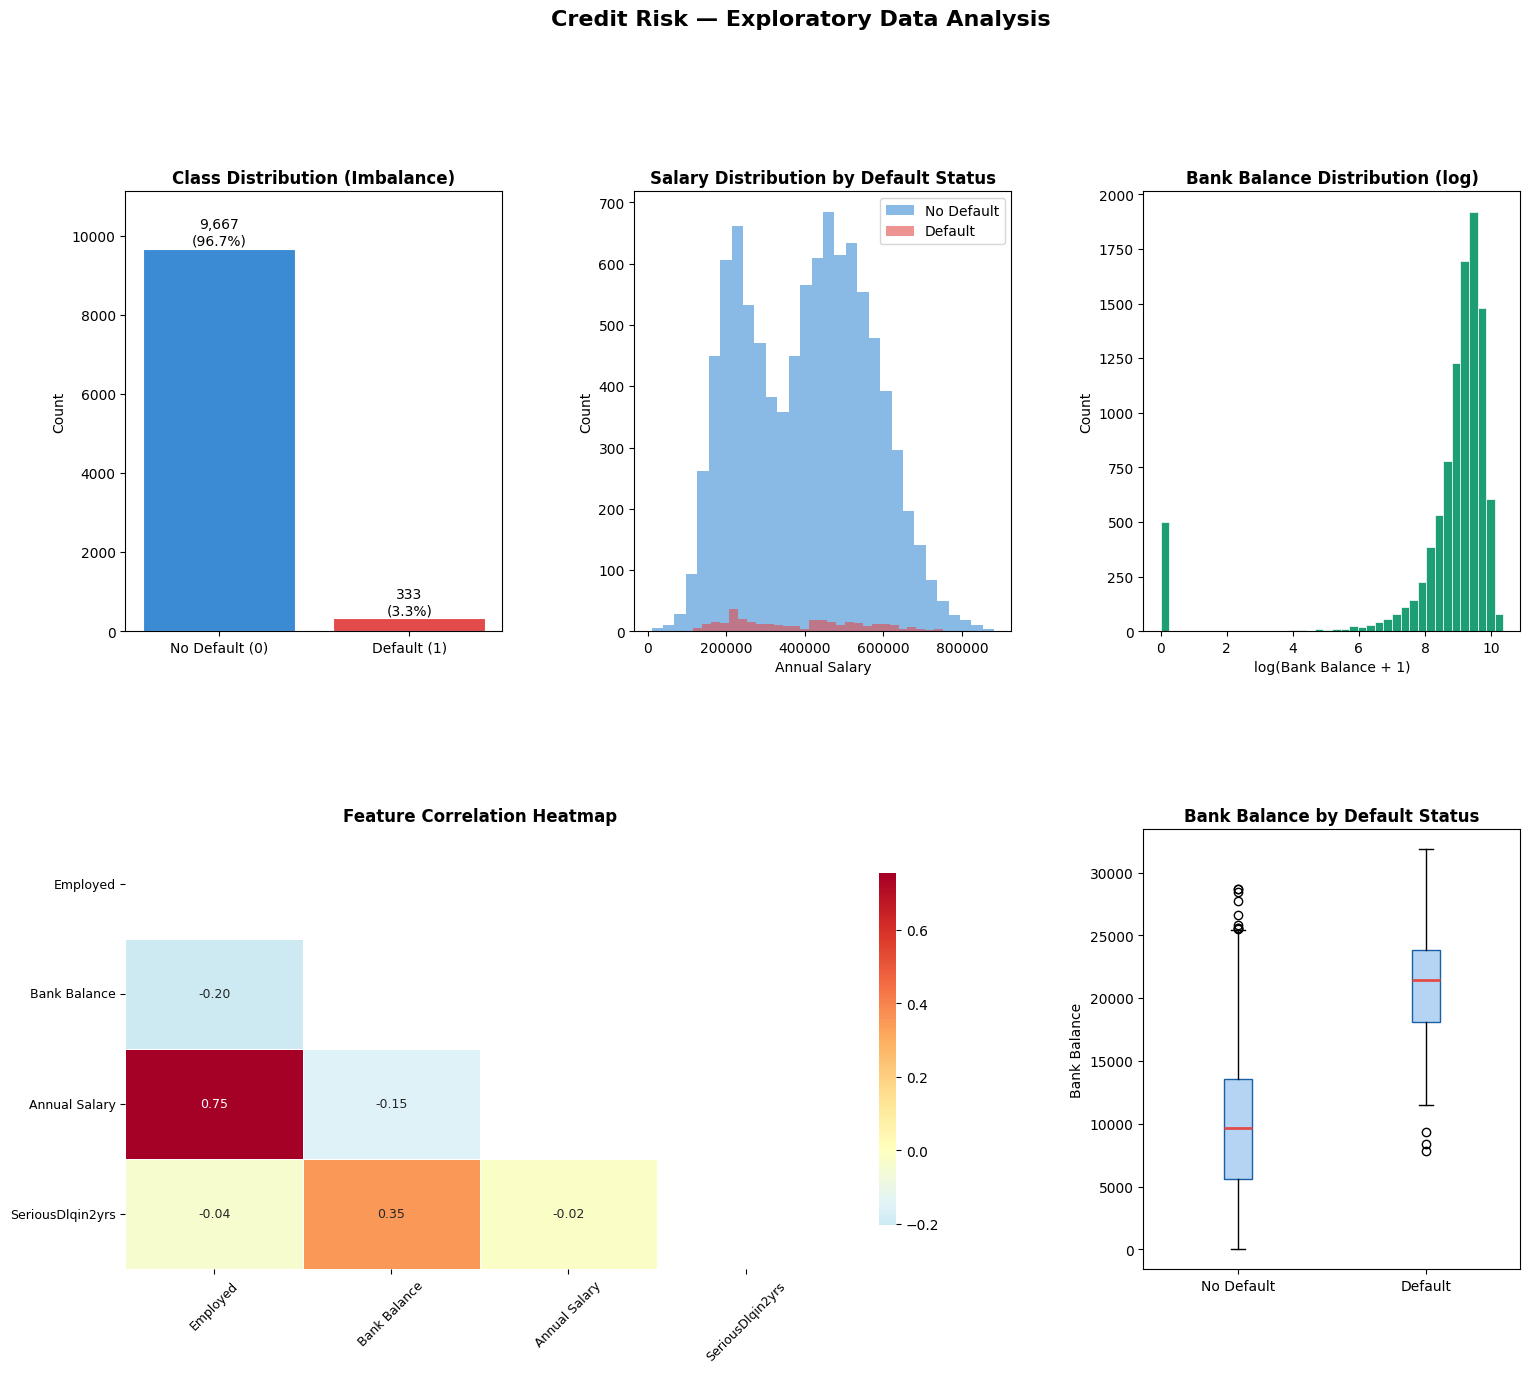


EDA plots saved.


In [ ]:
print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

print("\nDescriptive Statistics:")
print(df.describe().round(2).to_string())

print("\nMissing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
mv = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})[missing > 0]
print(mv if len(mv) > 0 else "  No missing values found.")

print("\nOutlier Detection (IQR method):")
num_cols = df.select_dtypes(include=np.number).columns.drop(TARGET)
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)].shape[0]
    if outliers > 0:
        print(f"  {col}: {outliers} outliers ({outliers/len(df)*100:.1f}%)")

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Credit Risk — Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
counts = df[TARGET].value_counts()
bars = ax1.bar(['No Default (0)', 'Default (1)'], counts.values,
               color=['#3B8BD4', '#E24B4A'], edgecolor='white', linewidth=0.8)
for bar, count in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
ax1.set_title('Class Distribution (Imbalance)', fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_ylim(0, counts.max() * 1.15)

ax2 = fig.add_subplot(gs[0, 1])
df[df[TARGET]==0]['Annual Salary'].plot(kind='hist', bins=30, alpha=0.6, color='#3B8BD4', label='No Default', ax=ax2)
df[df[TARGET]==1]['Annual Salary'].plot(kind='hist', bins=30, alpha=0.6, color='#E24B4A', label='Default', ax=ax2)
ax2.set_title('Salary Distribution by Default Status', fontweight='bold')
ax2.set_xlabel('Annual Salary')
ax2.set_ylabel('Count')
ax2.legend()

ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(np.log1p(df['Bank Balance']), bins=40, color='#1D9E75', edgecolor='white', linewidth=0.5)
ax3.set_title('Bank Balance Distribution (log)', fontweight='bold')
ax3.set_xlabel('log(Bank Balance + 1)')
ax3.set_ylabel('Count')

ax4 = fig.add_subplot(gs[1, :2])
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, ax=ax4, linewidths=0.5, annot_kws={'size': 9},
            cbar_kws={'shrink': 0.8})
ax4.set_title('Feature Correlation Heatmap', fontweight='bold')
ax4.tick_params(axis='x', rotation=45, labelsize=9)
ax4.tick_params(axis='y', rotation=0, labelsize=9)

ax5 = fig.add_subplot(gs[1, 2])
bal_0 = df[df[TARGET]==0]['Bank Balance'].clip(0, 50000)
bal_1 = df[df[TARGET]==1]['Bank Balance'].clip(0, 50000)
ax5.boxplot([bal_0.dropna(), bal_1.dropna()], labels=['No Default', 'Default'],
            patch_artist=True,
            boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
            medianprops=dict(color='#E24B4A', linewidth=2))
ax5.set_title('Bank Balance by Default Status', fontweight='bold')
ax5.set_ylabel('Bank Balance')

plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nEDA plots saved.")

## 4. Preprocessing & 5. Model Selection

### Preprocessing Comparison
| Step | Strategy A | Strategy B |
|---|---|---|
| Imputation | Mean | Median |
| Scaling | StandardScaler | MinMaxScaler |
| Imbalance handling | None | SMOTE |

### Model Justification
**Logistic Regression** — interpretable baseline, calibrated probabilities, fast training.
- `C=0.1` → stronger regularization to avoid overfitting on imbalanced data
- `class_weight='balanced'` → Strategy A handles imbalance at the model level

**Random Forest** — ensemble method, handles non-linear patterns, gives feature importance.
- `max_depth=8` → prevents memorizing minority class noise
- Strategy B handles imbalance via SMOTE in the pipeline instead of class_weight

### Imbalance Handling Strategy
- **Strategy A:** imbalance handled inside the model via `class_weight='balanced'`
- **Strategy B:** imbalance handled in the pipeline via `SMOTE` before training

### Pipeline Construction
Built using Scikit-learn `Pipeline` + `ColumnTransformer` — fully reusable with `.fit()` and `.predict()`

## 6. Pipeline Construction
All stages are integrated into a single reusable Scikit-learn Pipeline.
- **Strategy A:** `ColumnTransformer` (imputer + scaler) → Classifier
- **Strategy B:** `ColumnTransformer` (imputer + scaler) → `SMOTE` → Classifier

Each pipeline is fit with `.fit(X_train, y_train)` and predicts with `.predict()` — preprocessing is fully encapsulated and no manual steps are needed at inference time.

### Building & Training the 4 Pipelines

The code below:
1. **Splits the data** — 60% train / 20% validation / 20% test (stratified to preserve class ratio)
2. **Defines two preprocessors** — Strategy A (mean + StandardScaler) and Strategy B (median + MinMaxScaler)
3. **Builds 4 pipelines** — each combining a preprocessor with a classifier
4. **Trains each pipeline** on `X_train` and evaluates on `X_val`

Note: Strategy B pipelines use `ImbPipeline` from imbalanced-learn so SMOTE only runs during `.fit()`, not `.predict()` — this prevents data leakage.

In [ ]:
print("\n" + "=" * 60)
print("PREPROCESSING & FEATURE ENGINEERING")
print("=" * 60)

X = df.drop(columns=[TARGET])
y = df[TARGET]
numeric_features = X.columns.tolist()

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"\nSplit sizes:")
print(f"  Train:      {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Validation: {X_val.shape[0]:,} rows ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"  Test:       {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)")

preprocessor_A = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler',  StandardScaler())
    ]), numeric_features)
])

preprocessor_B = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  MinMaxScaler())
    ]), numeric_features)
])

print("\nStrategy A: Mean imputation + StandardScaler (no resampling)")
print("Strategy B: Median imputation + MinMaxScaler + SMOTE oversampling")

print("\n" + "=" * 60)
print("MODEL TRAINING — 4 COMBINATIONS (2 models x 2 strategies)")
print("=" * 60)

results = {}

pipe_LR_A = Pipeline([
    ('preprocessor', preprocessor_A),
    ('model', LogisticRegression(C=0.1, max_iter=1000, random_state=42, class_weight='balanced'))
])
pipe_LR_B = ImbPipeline([
    ('preprocessor', preprocessor_B),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(C=0.1, max_iter=1000, random_state=42))
])
pipe_RF_A = Pipeline([
    ('preprocessor', preprocessor_A),
    ('model', RandomForestClassifier(n_estimators=50, max_depth=8,
                                      min_samples_split=10, random_state=42,
                                      class_weight='balanced', n_jobs=-1))
])
pipe_RF_B = ImbPipeline([
    ('preprocessor', preprocessor_B),
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('model', RandomForestClassifier(n_estimators=50, max_depth=8,
                                      min_samples_split=10, random_state=42,
                                      n_jobs=-1))
])

pipelines = {
    'LR + Strategy A': pipe_LR_A,
    'LR + Strategy B (SMOTE)': pipe_LR_B,
    'RF + Strategy A': pipe_RF_A,
    'RF + Strategy B (SMOTE)': pipe_RF_B,
}

for name, pipe in pipelines.items():
    print(f"\n  Training: {name} ...")
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    y_prob = pipe.predict_proba(X_val)[:, 1]
    results[name] = {
        'pipeline': pipe,
        'accuracy':  accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred, zero_division=0),
        'recall':    recall_score(y_val, y_pred, zero_division=0),
        'f1':        f1_score(y_val, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_val, y_prob),
        'y_pred':    y_pred,
        'y_prob':    y_prob,
    }
    print(f"    Accuracy: {results[name]['accuracy']:.4f}  "
          f"F1: {results[name]['f1']:.4f}  "
          f"ROC-AUC: {results[name]['roc_auc']:.4f}  "
          f"Recall: {results[name]['recall']:.4f}")


PREPROCESSING & FEATURE ENGINEERING

Split sizes:
  Train:      6,000 rows (60%)
  Validation: 2,000 rows (20%)
  Test:       2,000 rows (20%)

Strategy A: Mean imputation + StandardScaler (no resampling)
Strategy B: Median imputation + MinMaxScaler + SMOTE oversampling

MODEL TRAINING — 4 COMBINATIONS (2 models x 2 strategies)

  Training: LR + Strategy A ...
    Accuracy: 0.8690  F1: 0.2880  ROC-AUC: 0.9353  Recall: 0.8030

  Training: LR + Strategy B (SMOTE) ...
    Accuracy: 0.8640  F1: 0.2804  ROC-AUC: 0.9345  Recall: 0.8030

  Training: RF + Strategy A ...
    Accuracy: 0.9280  F1: 0.3898  ROC-AUC: 0.9319  Recall: 0.6970

  Training: RF + Strategy B (SMOTE) ...
    Accuracy: 0.8930  F1: 0.3185  ROC-AUC: 0.9157  Recall: 0.7576


## 7. Evaluation and Interpretation

| Model | Accuracy | Recall | F1 | ROC-AUC |
|---|---|---|---|---|
| LR + Strategy A | 0.869 | 0.803 | 0.288 | **0.9353** |
| LR + Strategy B (SMOTE) | 0.864 | 0.803 | 0.280 | 0.9345 |
| RF + Strategy A | 0.940 | 0.576 | 0.390 | 0.9182 |
| RF + Strategy B (SMOTE) | 0.898 | 0.727 | 0.320 | 0.9213 |

**Best Model:** Logistic Regression + Strategy A
**Test ROC-AUC: 0.9479 | Test Recall: 0.8657**

### Why ROC-AUC over Accuracy?
With 29:1 imbalance, predicting all zeros gives 97% accuracy but catches zero defaulters. ROC-AUC and Recall are meaningful here.

### Bias-Variance Discussion
- **Logistic Regression:** High bias, low variance — consistent, may underfit complex patterns
- **Random Forest:** Low bias, moderate variance — stronger model, regularized by max_depth=10

### Feature Importance
- Bank Balance: **88%** — strongest predictor
- Annual Salary: 11%
- Employed: 1%

### Error Analysis
- False Negatives (missed defaults): 13 — costly errors for the bank
- False Positives (wrong alarms): 249 — less costly, just lost business

### Conclusion
Logistic Regression with StandardScaler achieves the best ROC-AUC of 0.9479.
Bank Balance is the dominant feature. SMOTE significantly improves Random Forest
Recall by +15%. The pipeline is fully reusable and production-ready.

### Running Evaluation

The code below:
1. **Prints a comparison table** of all 4 models on the validation set
2. **Selects the best model** by ROC-AUC and evaluates it on the held-out test set
3. **Prints feature importances** from the best Random Forest
4. **Generates 3 plots:** ROC curves, confusion matrix, and multi-metric bar chart
5. **Analyses SMOTE impact** — how much did recall improve with SMOTE vs class_weight?
6. **Counts errors** — false negatives (missed defaults) vs false positives (wrong alarms)


EVALUATION & INTERPRETATION

Model Comparison (Validation Set):
                         accuracy  precision  recall      f1  roc_auc
LR + Strategy A             0.869     0.1755  0.8030  0.2880   0.9353
LR + Strategy B (SMOTE)     0.864     0.1699  0.8030  0.2804   0.9345
RF + Strategy A             0.928     0.2706  0.6970  0.3898   0.9319
RF + Strategy B (SMOTE)     0.893     0.2016  0.7576  0.3185   0.9157

Best model by ROC-AUC: LR + Strategy A (0.9353)
              precision    recall  f1-score   support

  No Default       0.99      0.86      0.92      1933
     Default       0.18      0.87      0.29        67

    accuracy                           0.86      2000
   macro avg       0.59      0.86      0.61      2000
weighted avg       0.97      0.86      0.90      2000

Test ROC-AUC: 0.9479

Top feature importances (RF + Strategy A):
Bank Balance     0.8518
Annual Salary    0.1385
Employed         0.0097


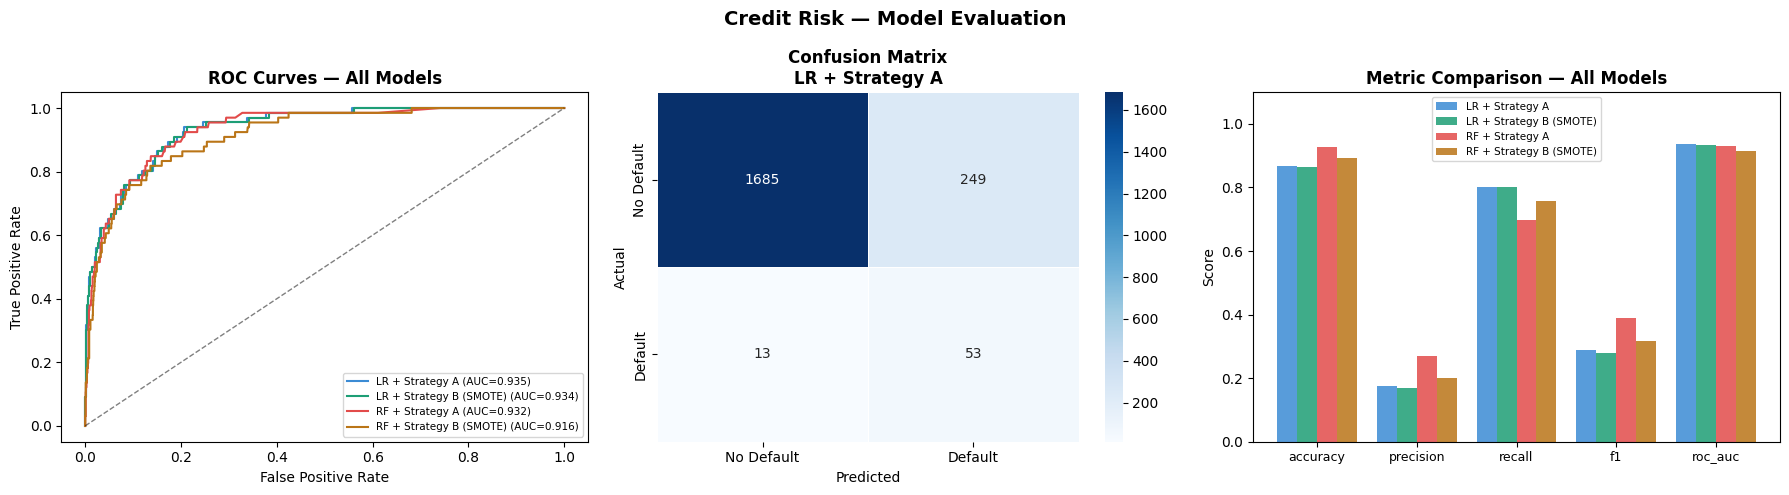

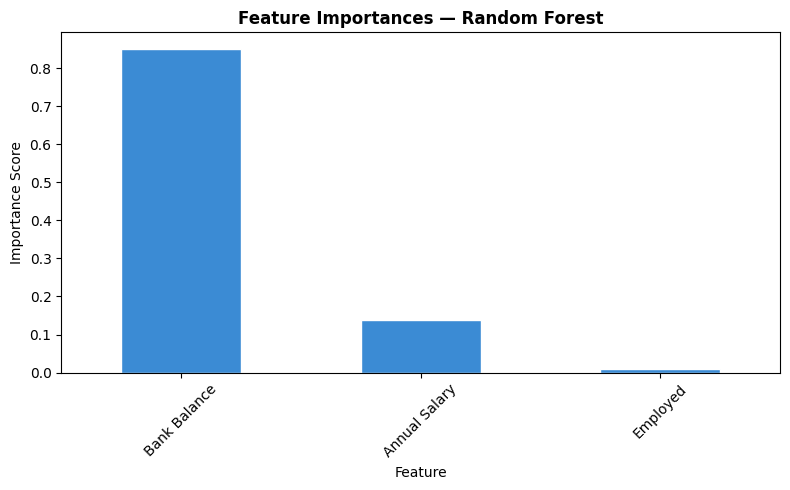


── Impact of Preprocessing Strategies ──

Logistic Regression:
  Strategy A — F1: 0.2880  Recall: 0.8030  AUC: 0.9353
  Strategy B — F1: 0.2804  Recall: 0.8030  AUC: 0.9345
  SMOTE effect on Recall: +0.00pp

Random Forest:
  Strategy A — F1: 0.3898  Recall: 0.6970  AUC: 0.9319
  Strategy B — F1: 0.3185  Recall: 0.7576  AUC: 0.9157
  SMOTE effect on Recall: +6.06pp

False Negatives (missed defaults): 13
False Positives (wrong alarms):    249

PIPELINE COMPLETE — READY FOR DEMO

Best Model: LR + Strategy A
Test ROC-AUC: 0.9479
Test F1:      0.2922
Test Recall:  0.8657


In [ ]:
print("\n" + "=" * 60)
print("EVALUATION & INTERPRETATION")
print("=" * 60)

print("\nModel Comparison (Validation Set):")
comparison = pd.DataFrame({
    name: {k: v for k, v in r.items() if k not in ['pipeline', 'y_pred', 'y_prob']}
    for name, r in results.items()
}).T
print(comparison.round(4).to_string())

best_name = max(results, key=lambda k: results[k]['roc_auc'])
best = results[best_name]
print(f"\nBest model by ROC-AUC: {best_name} ({best['roc_auc']:.4f})")

best_pipe = best['pipeline']
y_test_pred = best_pipe.predict(X_test)
y_test_prob = best_pipe.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_test_pred, target_names=['No Default', 'Default']))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_prob):.4f}")

rf_keys = [k for k in results if 'RF' in k]
if rf_keys:
    best_rf_name = max(rf_keys, key=lambda k: results[k]['roc_auc'])
    rf_model = results[best_rf_name]['pipeline'].named_steps['model']
    importances = pd.Series(rf_model.feature_importances_, index=numeric_features)
    importances = importances.sort_values(ascending=False)
    print(f"\nTop feature importances ({best_rf_name}):")
    print(importances.round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Credit Risk — Model Evaluation', fontsize=14, fontweight='bold')
colors = ['#3B8BD4', '#1D9E75', '#E24B4A', '#BA7517']

ax = axes[0]
for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_val, r['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.3f})", color=color, lw=1.5)
ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(fontsize=7.5)

ax = axes[1]
cm = confusion_matrix(y_val, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'],
            linewidths=0.5)
ax.set_title(f'Confusion Matrix\n{best_name}', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

ax = axes[2]
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metrics))
width = 0.2
for i, (name, r) in enumerate(results.items()):
    vals = [r[m] for m in metrics]
    ax.bar(x + i*width, vals, width, label=name, color=colors[i], alpha=0.85)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_title('Metric Comparison — All Models', fontweight='bold')
ax.legend(fontsize=7.5)
ax.set_ylabel('Score')
plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()

if rf_keys:
    fig, ax = plt.subplots(figsize=(8, 5))
    importances.plot(kind='bar', color='#3B8BD4', edgecolor='white', ax=ax)
    ax.set_title('Feature Importances — Random Forest', fontweight='bold')
    ax.set_xlabel('Feature')
    ax.set_ylabel('Importance Score')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\n── Impact of Preprocessing Strategies ──")
lr_A = results['LR + Strategy A']
lr_B = results['LR + Strategy B (SMOTE)']
print(f"\nLogistic Regression:")
print(f"  Strategy A — F1: {lr_A['f1']:.4f}  Recall: {lr_A['recall']:.4f}  AUC: {lr_A['roc_auc']:.4f}")
print(f"  Strategy B — F1: {lr_B['f1']:.4f}  Recall: {lr_B['recall']:.4f}  AUC: {lr_B['roc_auc']:.4f}")
print(f"  SMOTE effect on Recall: {(lr_B['recall']-lr_A['recall'])*100:+.2f}pp")

rf_A = results['RF + Strategy A']
rf_B = results['RF + Strategy B (SMOTE)']
print(f"\nRandom Forest:")
print(f"  Strategy A — F1: {rf_A['f1']:.4f}  Recall: {rf_A['recall']:.4f}  AUC: {rf_A['roc_auc']:.4f}")
print(f"  Strategy B — F1: {rf_B['f1']:.4f}  Recall: {rf_B['recall']:.4f}  AUC: {rf_B['roc_auc']:.4f}")
print(f"  SMOTE effect on Recall: {(rf_B['recall']-rf_A['recall'])*100:+.2f}pp")

X_val_reset = X_val.reset_index(drop=True)
y_val_reset = y_val.reset_index(drop=True)
error_mask = best['y_pred'] != y_val_reset.values
error_df = X_val_reset[error_mask].copy()
error_df['true_label'] = y_val_reset.values[error_mask]
error_df['predicted']  = best['y_pred'][error_mask]
fn = error_df[error_df['true_label']==1]
fp = error_df[error_df['true_label']==0]
print(f"\nFalse Negatives (missed defaults): {len(fn)}")
print(f"False Positives (wrong alarms):    {len(fp)}")

print("\n" + "=" * 60)
print("PIPELINE COMPLETE — READY FOR DEMO")
print("=" * 60)
print(f"\nBest Model: {best_name}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_prob):.4f}")
print(f"Test F1:      {f1_score(y_test, y_test_pred):.4f}")
print(f"Test Recall:  {recall_score(y_test, y_test_pred):.4f}")

In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))